## Neural Networks

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf 
from tensorflow import keras

### Perceptrons:

In [4]:
from sklearn.datasets import load_iris
from sklearn.linear_model import Perceptron

data = load_iris()
x = data.data[:,(2,3)] # petal length and width
y = (data.target == 0).astype(np.int64) # setosa

per_classifier = Perceptron()
per_classifier.fit(x,y)


,"penalty penalty: {'l2','l1','elasticnet'}, default=NoneThe penalty (aka regularization term) to be used.",None
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term if regularization isused.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with `0 <= l1_ratio <= 1`.`l1_ratio=0` corresponds to L2 penalty, `l1_ratio=1` to L1.Only used if `penalty='elasticnet'`... versionadded:: 0.24",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, the iterations will stopwhen (loss > previous_loss - tol)... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.",0
,"eta0 eta0: float, default=1Constant by which the updates are multiplied.",1.0
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"random_state random_state: int, RandomState instance or None, default=0Used to shuffle the training data, when ``shuffle`` is set to``True``. Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",0


#### MLP

In [5]:
fashion_mnist = keras.datasets.fashion_mnist
(x_train,y_train),(x_test,y_test) = fashion_mnist.load_data()

Scaling:

In [6]:
x_valid,x_train = x_train[:5000] / 255.0 , x_train[5000:] / 255.0
y_valid,y_train = y_train[:5000] / 255.0,y_train[5000:] / 255.0

In [7]:
model = keras.models.Sequential()
model.add(keras.layers.Flatten(input_shape=[28,28]))
model.add(keras.layers.Dense(300,activation='relu'))
model.add(keras.layers.Dense(100,activation='relu'))
model.add(keras.layers.Dense(10,activation='softmax'))

c:\Users\augusto\.vscode\Data Sci and Ml\Data\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

Layers:

In [9]:
hidden2 = model.layers[2]
print(hidden2.name)

print(hidden2.get_weights())

dense_1
[array([[ 0.07854744,  0.02380271, -0.10848315, ..., -0.03712253,
        -0.06041643,  0.10134061],
       [ 0.08732145,  0.01626369,  0.07595991, ..., -0.05081277,
        -0.08788662,  0.00916249],
       [ 0.0903445 ,  0.04552018,  0.02457891, ...,  0.00868764,
         0.03983473,  0.02519796],
       ...,
       [ 0.05870243,  0.07063165,  0.08576214, ...,  0.07410509,
         0.10029192,  0.0523259 ],
       [ 0.09350275, -0.0175318 , -0.11263901, ..., -0.10455485,
         0.09762757, -0.02192494],
       [-0.10828085, -0.02665762, -0.00743078, ...,  0.07811483,
         0.11070672,  0.0731219 ]], shape=(300, 100), dtype=float32), array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0

Compiling

In [10]:
model.compile(loss='sparse_categorical_crossentropy',
              optimizer='sgd',
              metrics=['accuracy'])

In [11]:
training = model.fit(x_train,y_train,epochs=5,
                     validation_data=(x_valid,y_valid))

Epoch 1/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.1007 - loss: 0.0145 - val_accuracy: 0.0914 - val_loss: 0.0011
Epoch 2/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 19s 6ms/step - accuracy: 0.1008 - loss: 7.5047e-04 - val_accuracy: 0.0914 - val_loss: 5.1042e-04
Epoch 3/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.1008 - loss: 4.1346e-04 - val_accuracy: 0.0914 - val_loss: 3.3254e-04
Epoch 4/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.1008 - loss: 2.8313e-04 - val_accuracy: 0.0914 - val_loss: 2.4557e-04
Epoch 5/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - accuracy: 0.1008 - loss: 2.1407e-04 - val_accuracy: 0.0914 - val_loss: 1.9417e-04


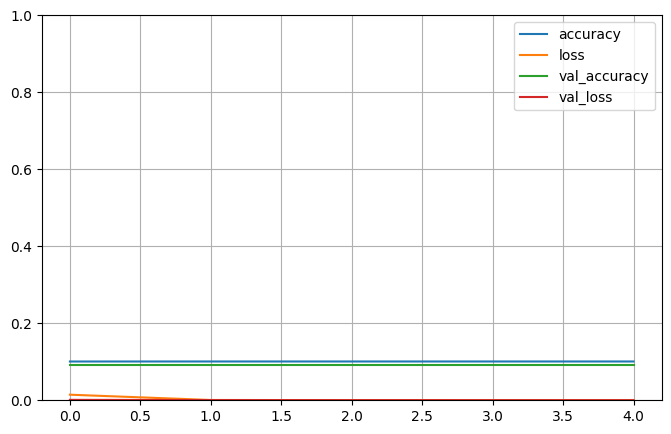

In [12]:
pd.DataFrame(training.history).plot(figsize=(8,5))
plt.grid(True)
plt.gca().set_ylim(0,1)
plt.show()

In [13]:
x_new = x_test[:3]
y_prob = model.predict(x_new)
print(y_prob.round(2))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step
[[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]
